# Exercise 3

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

## Part 1
Generate simulated values from the following distributions

(a) Exponential distribution   
(b) Normal distribution (at least with standard Box-Mueller)   
(c) Pareto distribution, with β = 1 and experiment with different values of k values: k = 2.05, k = 2.5, k = 3 and k = 4.   

Verify the results by comparing histograms with analytical results and perform tests for distribution type

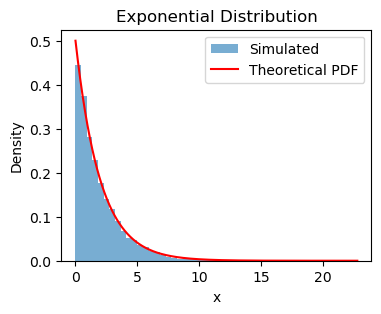

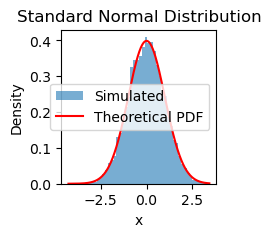

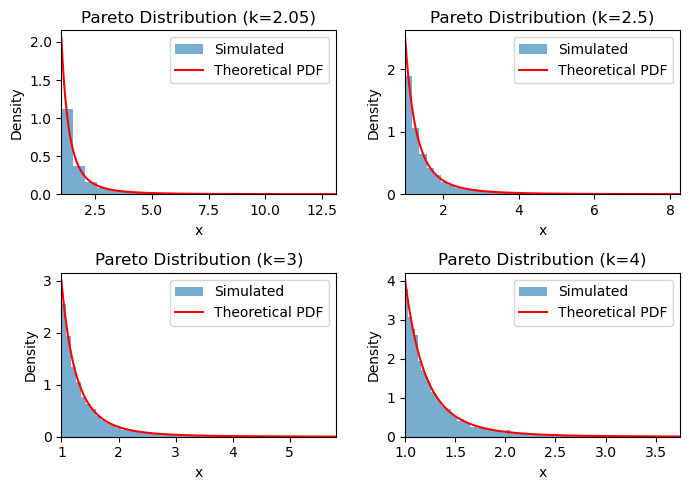

KS Test (Exponential): KS = 0.0130, p-value = 0.0671
KS Test (Normal): KS = 0.0060, p-value = 0.8587
KS Test (Pareto, k=2.05): KS = 0.0130, p-value = 0.0671
KS Test (Pareto, k=2.5): KS = 0.0130, p-value = 0.0671
KS Test (Pareto, k=3): KS = 0.0130, p-value = 0.0671
KS Test (Pareto, k=4): KS = 0.0130, p-value = 0.0671


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generate samples from three distributions using uniform random numbers

N = 10000
U = np.random.uniform(0, 1, size=N)

# --- Exponential distribution ---
lambda_exp = 0.5
samples_exp = -np.log(U) / lambda_exp

# --- Normal distribution (Box-Muller method) ---
U1 = np.random.uniform(0, 1, size=N // 2)
U2 = np.random.uniform(0, 1, size=N // 2)

R = np.sqrt(-2 * np.log(U1))
Theta = 2 * np.pi * U2

Z1 = R * np.cos(Theta)
Z2 = R * np.sin(Theta)

samples_normal = np.concatenate((Z1, Z2))

# --- Pareto distribution (beta = 1) ---
# Try different values of k: 2.05, 2.5, 3, 4
beta = 1
k_values = [2.05, 2.5, 3, 4]

samples_pareto = np.zeros((len(k_values), N))

for i, k in enumerate(k_values):
    samples_pareto[i, :] = beta * (U ** (-1 / k))


# ---------- Exponential plot ----------
x = np.linspace(0, np.max(samples_exp), N)
pdf_exp = lambda_exp * np.exp(-lambda_exp * x)

plt.figure(figsize=(4, 3))
plt.hist(samples_exp, bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x, pdf_exp, 'r', label="Theoretical PDF")
plt.title("Exponential Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()


# ---------- Normal plot ----------
x = np.linspace(np.min(samples_normal), np.max(samples_normal), N)
pdf_norm = stats.norm.pdf(x, loc=0, scale=1)

plt.figure(figsize=(2, 2))
plt.hist(samples_normal, bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x, pdf_norm, 'r', label="Theoretical PDF")
plt.title("Standard Normal Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()


# ---------- Pareto plots (all k values) ----------
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    ax = axes[idx]
    X_pareto = samples_pareto[idx, :]

    # Histogram of simulated values
    ax.hist(X_pareto, bins=500, density=True, alpha=0.6, label="Simulated")

    # Theoretical PDF
    x = np.linspace(beta, np.percentile(X_pareto, 99.5), N)
    pdf_pareto = k * beta**k / x**(k + 1)
    ax.plot(x, pdf_pareto, 'r', label="Theoretical PDF")

    ax.set_xlim(beta, np.percentile(X_pareto, 99.5))

    ax.set_title(f"Pareto Distribution (k={k})")
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()


# ---------- Kolmogorov–Smirnov tests ----------

# Exponential
ks_stat_exp, p_value_exp = stats.kstest(samples_exp, 'expon', args=(0, 1 / lambda_exp))
print(f"KS Test (Exponential): KS = {ks_stat_exp:.4f}, p-value = {p_value_exp:.4f}")

# Normal
ks_stat_norm, p_value_norm = stats.kstest(samples_normal, 'norm')
print(f"KS Test (Normal): KS = {ks_stat_norm:.4f}, p-value = {p_value_norm:.4f}")

# Pareto
for i, k in enumerate(k_values):
    ks_stat_p, p_value_p = stats.kstest(samples_pareto[i, :], 'pareto', args=(k, 0, beta))
    print(f"KS Test (Pareto, k={k}): KS = {ks_stat_p:.4f}, p-value = {p_value_p:.4f}")

## Part 2

In [5]:
# Pareto distribution on [beta, infinity]
# Compare simulated mean and variance with theoretical values

N = 10000
beta = 1
k_values = [2.05, 2.5, 3, 4]

U = np.random.uniform(0, 1, size=N)

for k in k_values:
    # Generate sample
    sample = beta * (U ** (-1 / k))

    # Sample statistics
    sample_mean = np.mean(sample)
    sample_var = np.var(sample)

    # Theoretical values
    theoretical_mean = beta * k / (k - 1)
    theoretical_var = (beta**2 * k) / ((k - 1)**2 * (k - 2))

    print(f"Pareto Distribution (k = {k}):")
    print(f"Sample mean = {sample_mean:.4f}, Theoretical mean = {theoretical_mean:.4f}")
    print(f"Sample variance = {sample_var:.4f}, Theoretical variance = {theoretical_var:.4f}\n")


# Note:
# The large difference in variance for k = 2.05 happens because
# the theoretical variance becomes very large when k is close to 2.

Pareto Distribution (k = 2.05):
Sample mean = 1.9637, Theoretical mean = 1.9524
Sample variance = 4.8170, Theoretical variance = 37.1882

Pareto Distribution (k = 2.5):
Sample mean = 1.6784, Theoretical mean = 1.6667
Sample variance = 1.5381, Theoretical variance = 2.2222

Pareto Distribution (k = 3):
Sample mean = 1.5096, Theoretical mean = 1.5000
Sample variance = 0.6536, Theoretical variance = 0.7500

Pareto Distribution (k = 4):
Sample mean = 1.3398, Theoretical mean = 1.3333
Sample variance = 0.2155, Theoretical variance = 0.2222



## Part 3

In [6]:
# Generate 100 confidence intervals (95%) for the mean and variance 
# of a normal distribution using the Box-Muller method

import numpy as np
from scipy import stats

N = 10
confidence_intervals_mean = []
confidence_intervals_variance = []

for i in range(100):
    # Box-Muller method
    U1 = np.random.uniform(0, 1, size=N // 2)
    U2 = np.random.uniform(0, 1, size=N // 2)

    R = np.sqrt(-2 * np.log(U1))
    Theta = 2 * np.pi * U2

    Z1 = R * np.cos(Theta)
    Z2 = R * np.sin(Theta)

    sample_normal = np.concatenate((Z1, Z2))

    # Sample mean and variance
    sample_mean = np.mean(sample_normal)
    sample_var = np.var(sample_normal, ddof=1)

    # --- Confidence interval for the mean ---
    t_crit = stats.t.ppf(0.975, df=N - 1)  # 95% two-sided
    margin_mean = t_crit * np.sqrt(sample_var / N)
    ci_mean = (sample_mean - margin_mean, sample_mean + margin_mean)
    confidence_intervals_mean.append(ci_mean)

    # --- Confidence interval for the variance ---
    chi2_low = stats.chi2.ppf(0.025, df=N - 1)
    chi2_high = stats.chi2.ppf(0.975, df=N - 1)

    ci_var_low = (N - 1) * sample_var / chi2_high
    ci_var_high = (N - 1) * sample_var / chi2_low
    ci_var = (ci_var_low, ci_var_high)
    confidence_intervals_variance.append(ci_var)

# True values
true_mean = 0
true_variance = 1

# Count how many intervals contain the true mean
count_mean = sum(
    (ci[0] <= true_mean <= ci[1])
    for ci in confidence_intervals_mean
)

# Count how many intervals contain the true variance
count_variance = sum(
    (ci[0] <= true_variance <= ci[1])
    for ci in confidence_intervals_variance
)

observed_coverage_mean = count_mean / 100
observed_coverage_variance = count_variance / 100

print(f"Average CI for mean: {np.mean(confidence_intervals_mean, axis=0)}")
print(f"Average CI for variance: {np.mean(confidence_intervals_variance, axis=0)}")
print(f"Observed coverage (mean): {observed_coverage_mean:.3f}")
print(f"Observed coverage (variance): {observed_coverage_variance:.3f}")

Average CI for mean: [-0.67537816  0.67690814]
Average CI for variance: [0.44506173 3.13521657]
Observed coverage (mean): 0.940
Observed coverage (variance): 0.990


## Part 4

Shape of X_direct: (5000,)
Shape of X_comp: (5000,)


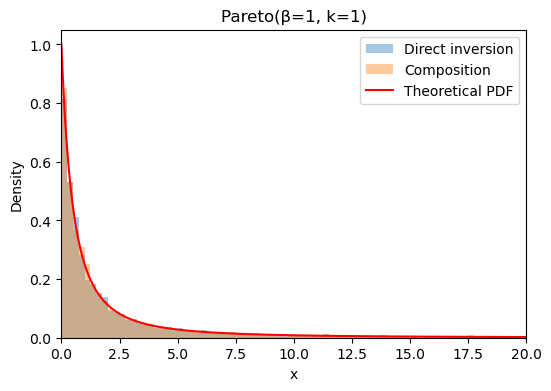

KS statistic between direct and composition: 0.0264, p-value: 0.0613


In [13]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

k = 1
beta = 1
N=5000
np.random.seed(42)

X_direct = np.zeros(N)
# Direct inversion method
U = np.random.uniform(0, 1, size=N)
X_direct = beta * (U ** (-1 / k)-1) 

# Composition method
U_exp = np.random.uniform(0, 1, size=N)
Y = -np.log(U_exp) / k  


X_comp = np.zeros(N)

U_exp = np.random.uniform(0, 1, size=N)
for i in range(N):
    X_comp[i] = -np.log(U_exp[i]) / Y[i]

print("Shape of X_direct:", X_direct.shape)
print("Shape of X_comp:", X_comp.shape)

edges = np.linspace(0,50,201)

x = np.linspace(0, np.percentile(X_comp, 99.5), N)
pdf_pareto = k / (k+x)**2

# Plotting
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(X_direct, bins=edges, density=True, alpha=0.4, label="Direct inversion")
ax.hist(X_comp, bins=edges, density=True, alpha=0.4, label="Composition")
ax.plot(x, pdf_pareto, 'r', label="Theoretical PDF")
ax.set_xlim(0, 20)
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title(f"Pareto(β={beta}, k={k})")
ax.legend()
plt.savefig("pareto_comparison.png", dpi=300)
plt.show()

ks_between = stats.ks_2samp(X_direct, X_comp)
print(f"KS statistic between direct and composition: {ks_between.statistic:.4f}, p-value: {ks_between.pvalue:.4f}")